In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plt.style.use('sci.mplstyle')

In [3]:
def luu_file(filename, u, err, L, k):
    n = u.shape[0]

    with open(filename, "w", encoding="utf-8") as file:
        file.write(f"### Ket qua tai vong lap {k}\n")
        file.write(f"### Max error = {np.max(err):.6e}\n")
        file.write("#" * 80 + "\n")
        file.write(f"### {'x':>15s} {'y':>15s} {'V':>15s} {'Error':>15s}\n")

        for i in range(n):
            for j in range(n):
                x = i * L / (n - 1)
                y = j * L / (n - 1)
                file.write(f"    {x:15.6f} {y:15.6f} {u[i,j]:15.6f} {err[i,j]:15.6e}\n")
            file.write("\n")

In [4]:
def doc_file_ketqua(filename): #dung de doc file ket qua
    x, y, V, err = np.loadtxt(filename, unpack=True, comments="#")

    # Lay so diem luoi tu file

    # unique co nghia la so day x ma co so khac nhau
    x_unique = np.unique(x)
    y_unique = np.unique(y)

    # lay len se ra duoc so diem x va y khac nhau -> luoi
    nx = len(x_unique)
    ny = len(y_unique)

    print("File:", filename)
    print("nx =", nx)
    print("ny =", ny)
    print("So diem trong file =", len(x))
    print("nx * ny =", nx * ny)

    # Neu file luu theo for i roi luu for j
    X = x.reshape(nx, ny)
    Y = y.reshape(nx, ny)
    V2D = V.reshape(nx, ny)
    err2D = err.reshape(nx, ny)

    return x_unique, y_unique, X, Y, V2D, err2D

In [5]:
def hamtinh_laplace_gauss_seidel(u, L, h, rho, N_max=100000, err_max=1e-6, filename="bai3"):
    n = u.shape[0]  # kich thuoc luoi n x n

    for k in range(N_max):
        u_old = u.copy()  # luu nghiem cua vong lap truoc

        # cap nhat cac diem ben trong theo cong thuc Gauss-Seidel
        for i in range(1, n - 1):
            for j in range(1, n - 1):
                u[i, j] = 0.25 * (
                    u[i + 1, j]  # diem ben phai
                    + u[i - 1, j]  # diem ben trai
                    + u[i, j + 1]  # diem ben tren
                    + u[i, j - 1]  # diem ben duoi
                    + h**2 * np.pi * rho[i, j] 

                )
        # khi dang tinh u[i,j] thi u[i+1, j] va u[i, j + 1] la chua cap nhat nen no la old
        # trong khi do u[i-1, j] va u[i, j - 1] la chap nhat roi nen no la new

        # tinh sai so giua hai lan lap lien tiep
        err = np.abs(u - u_old)

        # lay sai so lon nhat tren toan bo luoi
        max_err = np.max(err)

        # kiem tra dieu kien hoi tu
        if max_err < err_max:
            print(f"Gauss-Seidel hoi tu sau {k} vong lap, max_err = {max_err:.3e}")

            # luu nghiem va sai so ra file
            luu_file(filename + "_gs_result.txt", u, err, L, k)

            return u

    # truong hop khong hoi tu sau N_max vong lap
    print(f"Gauss-Seidel khong hoi tu sau {N_max} vong lap, max_err = {max_err:.3e}")
    # luu ket qua cuoi cung ra file
    luu_file(filename + "_gs_result_khonghoitu.txt", u, err, L, N_max)

    return u

In [6]:
def dieukienbien_bai3(n, L, u_bien):

    # Tao mang dien the ban dau
    u = np.zeros((n, n), dtype=float)

    u[:, 0]  = u_bien      # bottom, y = 0
    u[:, -1] = u_bien      # top,    y = L
    u[0, :]  = u_bien      # left,   x = 0
    u[-1, :] = u_bien      # right,  x = L

    x = np.linspace(0, L, n)
    y = np.linspace(0, L, n)

    return u, x, y

In [7]:
#mat_do_dien_tich_y_1
#4 cai duong

def matdo_dientich_cau1(n,rho0, rho1):
    
    n_x = n
    n_y = n

    rho = np.zeros([n_x, n_y]) #khoi tao mat do dien tich theo x va y

    tam_hv_x = (n_x/2)
    tam_hv_y = (n_y/2)
    canh_hv =  (n_x/2)

    rho[int(tam_hv_x - canh_hv/2),int(tam_hv_y + canh_hv/2)] = rho0 #(canh trai, phia tren)

    rho[int(tam_hv_x + canh_hv/2),int(tam_hv_y + canh_hv/2)] = rho0 #(canh phai, phia tren)

    rho[int(tam_hv_x - canh_hv/2),int(tam_hv_y - canh_hv/2)] = rho0 #(canh trai, phia duoi)

    rho[int(tam_hv_x + canh_hv/2),int(tam_hv_y - canh_hv/2)] = rho0 #(canh phai, phia duoi)

    return rho

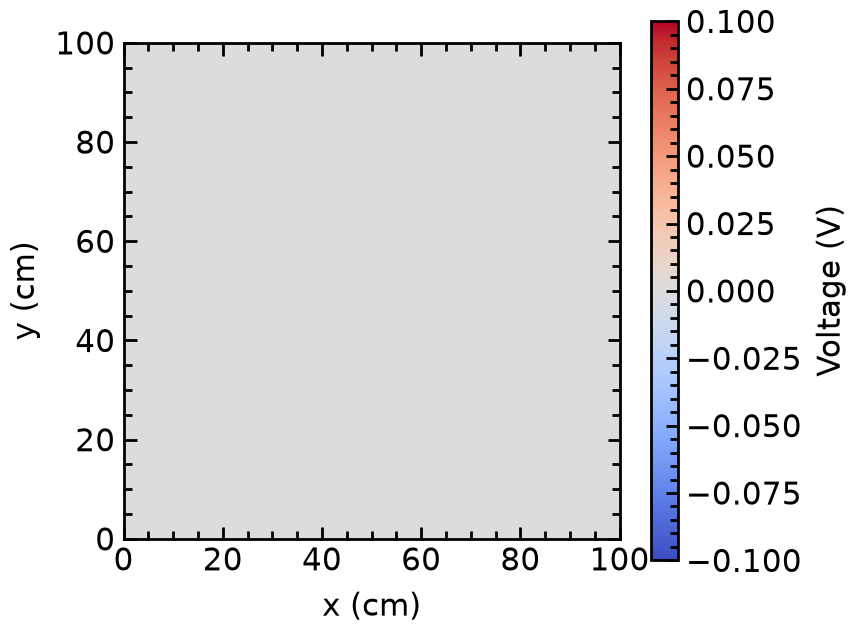

In [8]:
L = 1
n = 100
u_bien = 0



u0_bai3, x, y = dieukienbien_bai3(
    n,
    L,
    u_bien,
)

plt.figure(figsize=(8, 7))
plt.imshow(u0_bai3.T, origin='lower', cmap='coolwarm',extent=[0, 100, 0, 100], )
plt.xlabel('x (cm)')
plt.ylabel('y (cm)')
plt.colorbar(label='Voltage (V)')
plt.show()
N_max = 100000
err_max = 1e-6

In [9]:
h = x[1] - x[0]

rho0 = 10000
rho1 = -10000

rho = matdo_dientich_cau1(n, rho0, rho1)

In [ ]:
u_gs_bai3 = hamtinh_laplace_gauss_seidel(u0_bai3.copy(), L, h, rho, N_max=100000, err_max=1e-6, filename="bai3c_giongnhau")

Gauss-Seidel hoi tu sau 7110 vong lap, max_err = 9.997e-07


In [ ]:
x_unique_bai3c_gauss, y_unique_bai3c_gauss, X_bai3c_gauss, Y_bai3c_gauss, V2D_bai3c_gauss, err2D_bai3c_gauss = doc_file_ketqua("bai3c_giongnhau_gs_result.txt")

In [10]:
#mat_do_dien_tich_y_2
#4 cai duong

def matdo_dientich_cau2(n,rho0, rho1):
    
    n_x = n
    n_y = n

    rho = np.zeros([n_x, n_y]) #khoi tao mat do dien tich theo x va y

    tam_hv_x = (n_x/2)
    tam_hv_y = (n_y/2)
    canh_hv =  (n_x/2)

    rho[int(tam_hv_x - canh_hv/2),int(tam_hv_y + canh_hv/2)] = rho0 #(canh trai, phia tren)

    rho[int(tam_hv_x + canh_hv/2),int(tam_hv_y + canh_hv/2)] = -rho0 #(canh phai, phia tren)

    rho[int(tam_hv_x - canh_hv/2),int(tam_hv_y - canh_hv/2)] = -rho0 #(canh trai, phia duoi)

    rho[int(tam_hv_x + canh_hv/2),int(tam_hv_y - canh_hv/2)] = rho0 #(canh phai, phia duoi)

    return rho

In [11]:
rho_y2 = matdo_dientich_cau2(n, rho0, rho1)

In [12]:
u_gs_bai3 = hamtinh_laplace_gauss_seidel(u0_bai3.copy(), L, h, rho_y2, N_max=100000, err_max=1e-6, filename="bai3c_khacnhau")

Gauss-Seidel hoi tu sau 2001 vong lap, max_err = 9.997e-07
